In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [33]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [35]:
df.describe()
df.isnull().sum()
df = df.drop(columns=["CustomerID"])

In [36]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [37]:
df.isnull().sum()

,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [38]:
df.columns

Index(['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

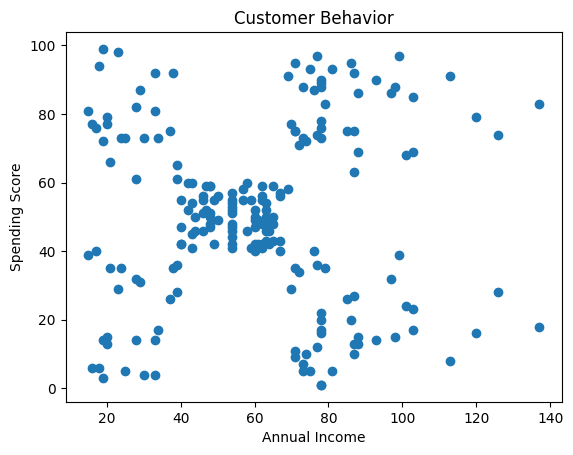

In [39]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Behavior")

plt.show()

In [40]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [41]:
from sklearn.cluster import KMeans

inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)


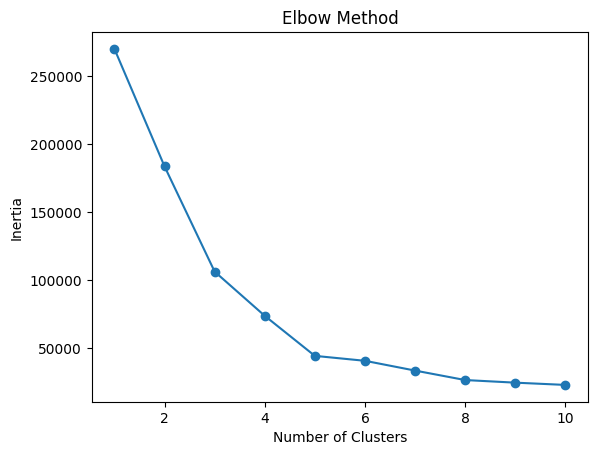

In [42]:
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [43]:
kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

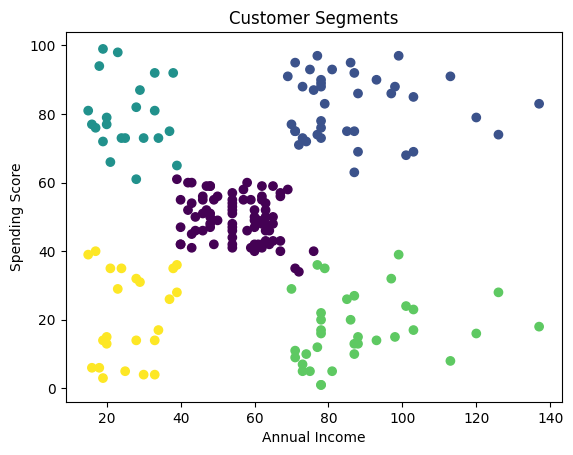

In [44]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")

plt.show()

In [45]:
df.groupby("Cluster").mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [46]:
df.groupby("Cluster").mean(numeric_only=True)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [47]:
df.to_csv("customer_segments.csv", index=False)


In [48]:
from google.colab import files
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

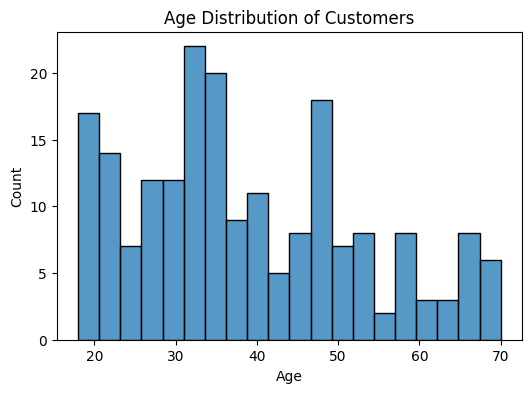

In [49]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")

plt.show()


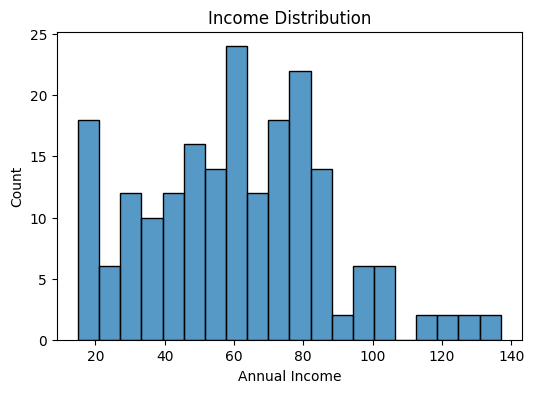

In [50]:
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=20)

plt.title("Income Distribution")
plt.xlabel("Annual Income")

plt.show()

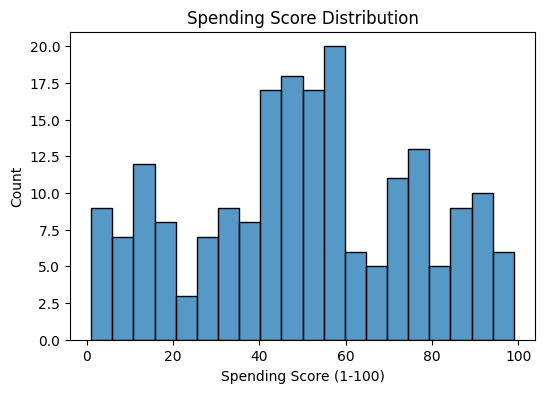

In [51]:
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=20)

plt.title("Spending Score Distribution")

plt.show()

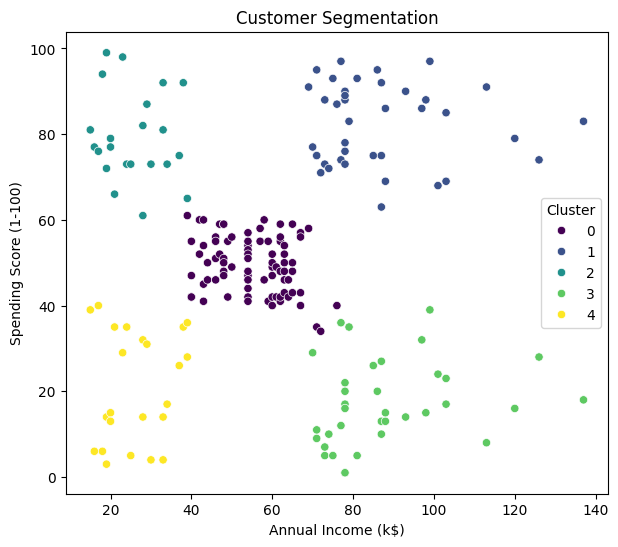

In [52]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title("Customer Segmentation")

plt.show()

In [53]:
df["Cluster"].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [54]:
df.to_csv("customer_segments.csv", index=False)


In [55]:
from google.colab import files
files.download("customer_segments.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cluster Insights

Cluster 0
Customers with low income and low spending score. These customers are price sensitive and respond well to discount promotions.

Cluster 1
Customers with high income and high spending score. These are premium customers who should receive exclusive product recommendations.

Cluster 2
Customers with moderate income and spending levels. Loyalty programs may encourage them to increase their purchases.

Cluster 3
Customers with high income but moderate spending. Marketing strategies could encourage them to spend more through premium product offers.

Cluster 4
Customers with lower income but moderate spending. Retailers can target them with seasonal discounts and bundle deals

In [56]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [57]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [58]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


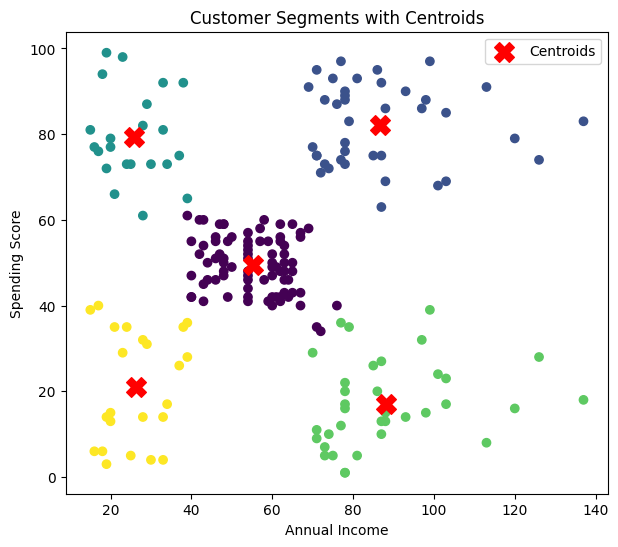

In [59]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    c="red",
    s=200,
    marker="X",
    label="Centroids"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments with Centroids")

plt.legend()

plt.show()

In [60]:
cluster_names = {
    0: "Budget Customers",
    1: "Premium Customers",
    2: "Average Customers",
    3: "High Spenders",
    4: "Moderate Customers"
}

df["Segment"] = df["Cluster"].map(cluster_names)

df.head()


,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,Male,19,15,39,4,Moderate Customers
1,Male,21,15,81,2,Average Customers
2,Female,20,16,6,4,Moderate Customers
3,Female,23,16,77,2,Average Customers
4,Female,31,17,40,4,Moderate Customers


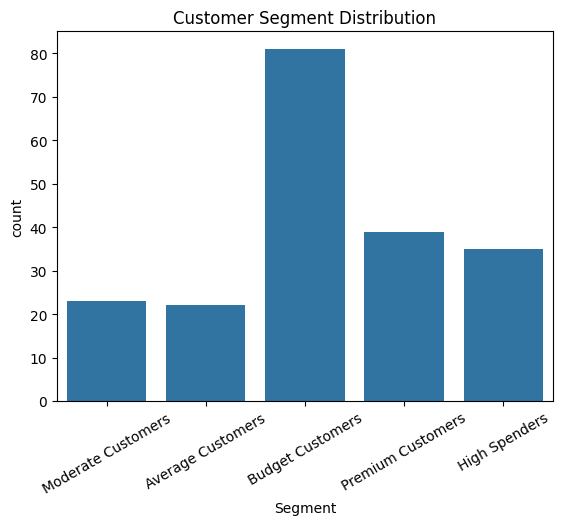

In [61]:
sns.countplot(x="Segment", data=df)

plt.xticks(rotation=30)

plt.title("Customer Segment Distribution")

plt.show()

In [63]:
df.to_csv("customer_segments.csv", index=False)

In [64]:
from google.colab import files

files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cluster Interpretation

Cluster 0
Customers with lower income and low spending score. These customers are price sensitive and likely respond to discount-based promotions.

Cluster 1
Customers with higher income and high spending score. These are premium customers who tend to purchase high-value products.

Cluster 2
Customers with moderate income and moderate spending behavior. These represent regular shoppers who may respond well to loyalty programs.

Cluster 3
Customers with high spending scores. These customers are high-value shoppers and should be targeted with exclusive offers.

Cluster 4
Customers with moderate income but lower spending. Marketing campaigns may encourage them to increase their purchasing frequency.

Business Insights

Customer segmentation helps retailers understand purchasing behavior across different customer groups.

Key insights from the clustering analysis include:

High-income customers tend to have higher spending scores.

Certain customer segments show strong purchasing behavior and represent valuable targets for premium product promotions.

Price-sensitive customers may respond better to discount campaigns and promotional offers.

Retail companies can use these insights to design targeted marketing strategies instead of using a single generic marketing approach.

Conclusion

Create another Text cell.

Conclusion

This project demonstrated how clustering techniques can be used to analyze customer behavior and identify meaningful customer segments.

Using the K-Means clustering algorithm, customers were grouped based on income and spending patterns. These segments reveal important behavioral trends that can help retailers improve marketing strategies and customer engagement.

Customer segmentation allows businesses to move from generalized marketing campaigns to more personalized and data-driven strategies.